# Task 3.1 — Two-Component Ablation Study
**Paper:** DynaMMo: Mining and Summarization of Coevolving Sequences with Missing Values  
**Authors:** Li, McCann, Pollard, Faloutsos — KDD 2009  
**Components Ablated:**
1. **RTS Smoother** (backward inference pass — Paper Section 3.1, Equations 8–10)
2. **Diagonal Observation Noise Constraint** (R matrix structure — Paper Section 3.1, Equation 13)

Each ablation is tested independently: when ablating one component, all other parts of the method remain at full settings.  
**Evaluation metric:** RMSE on held-out missing values (same metric as Task 2.2)


In [1]:
# ============================================================
# SETUP — imports, seed, results directory
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numpy.linalg import inv, slogdet
import warnings, os
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

RESULTS_DIR = os.path.join(os.getcwd(), 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')
print(f'Random seed: {RANDOM_SEED}')


Results will be saved to: /Users/ashwin.s/results
Random seed: 42


In [2]:
# ============================================================
# DATASET — same as Task 2.1 and 2.2 (for consistency)
# Synthetic air-quality-style co-evolving sequences
# T=300, d=8 sensors, k=2 latent factors, 15% missing
# ============================================================
def make_dataset(T=300, d=8, k=2, missing_rate=0.15, seed=42):
    rng = np.random.RandomState(seed)
    t   = np.linspace(0, 6*np.pi, T)
    Z   = np.zeros((T, k))
    Z[:, 0] = np.sin(t) + 0.3 * np.sin(3*t)
    Z[:, 1] = np.cumsum(rng.randn(T) * 0.02)
    Z[:, 1] = (Z[:,1] - Z[:,1].mean()) / (Z[:,1].std() + 1e-8)
    C   = rng.randn(d, k) * 0.8
    Xt  = Z @ C.T + rng.randn(T, d) * 0.2
    Xm  = Xt.copy()
    mm  = rng.rand(T, d) < missing_rate
    for _ in range(4):
        t0  = rng.randint(20, T-30)
        dur = rng.randint(5, 20)
        j   = rng.randint(0, d)
        mm[t0:t0+dur, j] = True
    mm[:10] = False; mm[-10:] = False
    Xm[mm] = np.nan
    return Xt, Xm, mm

Xt, Xm, mm = make_dataset(seed=RANDOM_SEED)
print(f'Dataset: T={Xt.shape[0]}, d={Xt.shape[1]}, missing={mm.sum()} ({mm.mean()*100:.1f}%)')


Dataset: T=300, d=8, missing=384 (16.0%)


In [3]:
# ============================================================
# DYNAMMO CLASS — supports both ablations via flags
# use_smoother : if False → Ablation 1 (no RTS smoother)
# full_R       : if False → Ablation 2 (full R, not diagonal)
# ============================================================
class DynaMMo:
    def __init__(self, n_dim_state=2, n_iter=30, tol=1e-3,
                 use_smoother=True, diagonal_R=True, verbose=False):
        self.k           = n_dim_state
        self.n_iter      = n_iter
        self.tol         = tol
        self.use_smoother = use_smoother   # ABLATION 1 flag
        self.diagonal_R  = diagonal_R     # ABLATION 2 flag
        self.verbose     = verbose

    def _init_params(self, d):
        k = self.k; np.random.seed(0)
        self.A   = np.eye(k)*0.9 + 0.01*np.random.randn(k,k)
        U, _     = np.linalg.qr(np.random.randn(d, k))
        self.C   = U[:, :k]
        self.Q   = np.eye(k)
        self.R   = np.eye(d) * 0.5
        self.mu0 = np.zeros(k)
        self.V0  = np.eye(k)

    def _kalman_filter(self, X, mask):
        T, d = X.shape; k = self.k
        A, C, Q, R = self.A, self.C, self.Q, self.R
        mf = np.zeros((T,k)); Vf = np.zeros((T,k,k))
        mp = np.zeros((T,k)); Vp = np.zeros((T,k,k)); ll = 0.0
        for t in range(T):
            mp_ = self.mu0.copy() if t==0 else A @ mf[t-1]
            Vp_ = self.V0.copy()  if t==0 else A @ Vf[t-1] @ A.T + Q
            mp[t], Vp[t] = mp_, Vp_
            obs = np.where(mask[t])[0]
            if len(obs) == 0:
                mf[t], Vf[t] = mp_, Vp_; continue
            Co  = C[obs,:]; Ro = R[np.ix_(obs,obs)]; xo = X[t,obs]
            inn = xo - Co @ mp_
            S   = Co @ Vp_ @ Co.T + Ro
            try:    Si = inv(S)
            except: Si = np.linalg.pinv(S)
            K       = Vp_ @ Co.T @ Si
            mf[t]   = mp_ + K @ inn
            Vf[t]   = (np.eye(k) - K @ Co) @ Vp_
            sg, ld  = slogdet(S)
            if sg > 0:
                ll += -0.5*(len(obs)*np.log(2*np.pi) + ld + inn @ Si @ inn)
        return mf, Vf, mp, Vp, ll

    def _rts_smoother(self, mf, Vf, mp, Vp):
        T = len(mf); k = self.k; A = self.A
        ms = np.zeros_like(mf); Vs = np.zeros_like(Vf); Vs1 = np.zeros_like(Vf)
        ms[-1] = mf[-1].copy(); Vs[-1] = Vf[-1].copy()
        for t in range(T-2, -1, -1):
            try:    Vi = inv(Vp[t+1])
            except: Vi = np.linalg.pinv(Vp[t+1])
            L       = Vf[t] @ A.T @ Vi
            ms[t]   = mf[t]  + L @ (ms[t+1] - mp[t+1])
            Vs[t]   = Vf[t]  + L @ (Vs[t+1]  - Vp[t+1]) @ L.T
            Vs1[t]  = L @ Vs[t+1]
        return ms, Vs, Vs1

    def fit(self, X):
        X = np.array(X, dtype=float); T, d = X.shape
        mask = ~np.isnan(X); Xw = np.where(mask, X, 0.0)
        self._init_params(d)
        self.ll_history_ = []; prev = -np.inf

        for it in range(self.n_iter):
            mf, Vf, mp, Vp, ll = self._kalman_filter(Xw, mask)

            # ABLATION 1: skip RTS smoother if use_smoother=False
            if self.use_smoother:
                ms, Vs, Vs1 = self._rts_smoother(mf, Vf, mp, Vp)
            else:
                ms, Vs, Vs1 = mf, Vf, np.zeros_like(Vf)

            self.ll_history_.append(ll)
            if it > 0 and abs(ll - prev) < self.tol: break
            prev = ll

            # Sufficient statistics
            Ezz  = np.array([Vs[t]+np.outer(ms[t],ms[t]) for t in range(T)])
            Em1  = np.array([Vs1[t]+np.outer(ms[t+1],ms[t]) for t in range(T-1)])
            Pz   = Ezz.sum(0); Pz1 = Ezz[:-1].sum(0)
            Pz2  = Ezz[1:].sum(0); Pzz = Em1.sum(0)
            Pxz  = sum(np.outer(Xw[t], ms[t]) for t in range(T))
            Pxx  = sum(np.outer(Xw[t], Xw[t]) for t in range(T))

            try:    self.A = Pzz @ inv(Pz1)
            except: self.A = Pzz @ np.linalg.pinv(Pz1)

            Qn = (Pz2 - self.A @ Pzz.T)/(T-1)
            self.Q = (Qn+Qn.T)/2 + 1e-5*np.eye(self.k)

            try:    self.C = Pxz @ inv(Pz)
            except: self.C = Pxz @ np.linalg.pinv(Pz)

            Rn = (Pxx - self.C @ Pxz.T) / T

            # ABLATION 2: full R vs diagonal R (paper uses diagonal)
            if self.diagonal_R:
                self.R = np.diag(np.maximum(np.diag(Rn), 1e-4))  # paper's constraint
            else:
                Rn = (Rn + Rn.T)/2
                self.R = Rn + 1e-4*np.eye(d)                     # ablated: full matrix

            self.mu0 = ms[0].copy(); self.V0 = Vs[0].copy()

        self.mu_s_ = ms; self.V_s_ = Vs
        self.mask_  = mask; self.T_ = T; self.d_ = d
        return self

    def impute(self, X):
        Xi = X.copy()
        for t in range(self.T_):
            miss = np.where(~self.mask_[t])[0]
            if len(miss) > 0:
                Xi[t, miss] = (self.C @ self.mu_s_[t])[miss]
        return Xi

def rmse(true, pred, mask):
    e = (true[mask] - pred[mask])**2
    return np.sqrt(e.mean()) if mask.any() else 0.0

print('DynaMMo class defined with ablation flags.')
print('  use_smoother=True/False → controls Ablation 1')
print('  diagonal_R=True/False   → controls Ablation 2')


DynaMMo class defined with ablation flags.
  use_smoother=True/False → controls Ablation 1
  diagonal_R=True/False   → controls Ablation 2


---
## Ablation 1: Removing the RTS Smoother (Backward Pass)

**Component being ablated:** The Rauch-Tung-Striebel (RTS) Smoother — the backward inference pass described in Paper Section 3.1, Equations (8)–(10).

**Role in the full method:** After the Kalman Filter computes the forward estimate `P(z_t | x_{1:t})` (using only past observations), the RTS Smoother refines each latent state estimate to `P(z_t | x_{1:T})` — incorporating all future observations as well. In DynaMMo this is critical for imputation: a missing value at time `t` benefits from observations at `t+50` if they share a common latent driver. Without the smoother, the imputed values at time `t` rely only on observations before `t`, making recovery of block-missing segments one-sided and systematically biased toward the pre-gap dynamics.

**What changes:** `use_smoother=False` → the EM E-step uses filtered states `μ_t^f` instead of smoothed states `μ_t^s`. All other components (Kalman Filter, EM M-step, imputation formula) remain identical.


In [4]:
# ============================================================
# ABLATION 1 EXPERIMENT
# Full DynaMMo (with RTS Smoother) vs Ablated (Filter Only)
# All other settings identical: k=2, n_iter=30, tol=1e-3
# ============================================================
print('Fitting Full DynaMMo (use_smoother=True) ...')
m_full = DynaMMo(n_dim_state=2, use_smoother=True,  diagonal_R=True, verbose=False)
m_full.fit(Xm)
Xi_full = m_full.impute(Xm)
r_full  = rmse(Xt, Xi_full, mm)

print('Fitting Ablated model (use_smoother=False) ...')
m_nosm = DynaMMo(n_dim_state=2, use_smoother=False, diagonal_R=True, verbose=False)
m_nosm.fit(Xm)
Xi_nosm = m_nosm.impute(Xm)
r_nosm  = rmse(Xt, Xi_nosm, mm)

print()
print(f'  Full DynaMMo (with RTS Smoother): RMSE = {r_full:.4f}')
print(f'  Ablated (Filter Only):            RMSE = {r_nosm:.4f}')
print(f'  Degradation from ablation:        +{(r_nosm/r_full - 1)*100:.1f}%')


Fitting Full DynaMMo (use_smoother=True) ...
Fitting Ablated model (use_smoother=False) ...

  Full DynaMMo (with RTS Smoother): RMSE = 0.2526
  Ablated (Filter Only):            RMSE = 0.2619
  Degradation from ablation:        +3.7%


**What the code does:** Fits two identical DynaMMo models — one with the RTS Smoother enabled (full method) and one with it disabled (filter-only, ablated version). Both use k=2 latent dimensions, 30 EM iterations, and the same dataset. RMSE is computed only on the held-out missing positions, matching the evaluation metric from Task 2.2.  
**Paper reference:** Section 3.1, Algorithm 1 — the smoother step (Equations 8–10) is the component being removed.


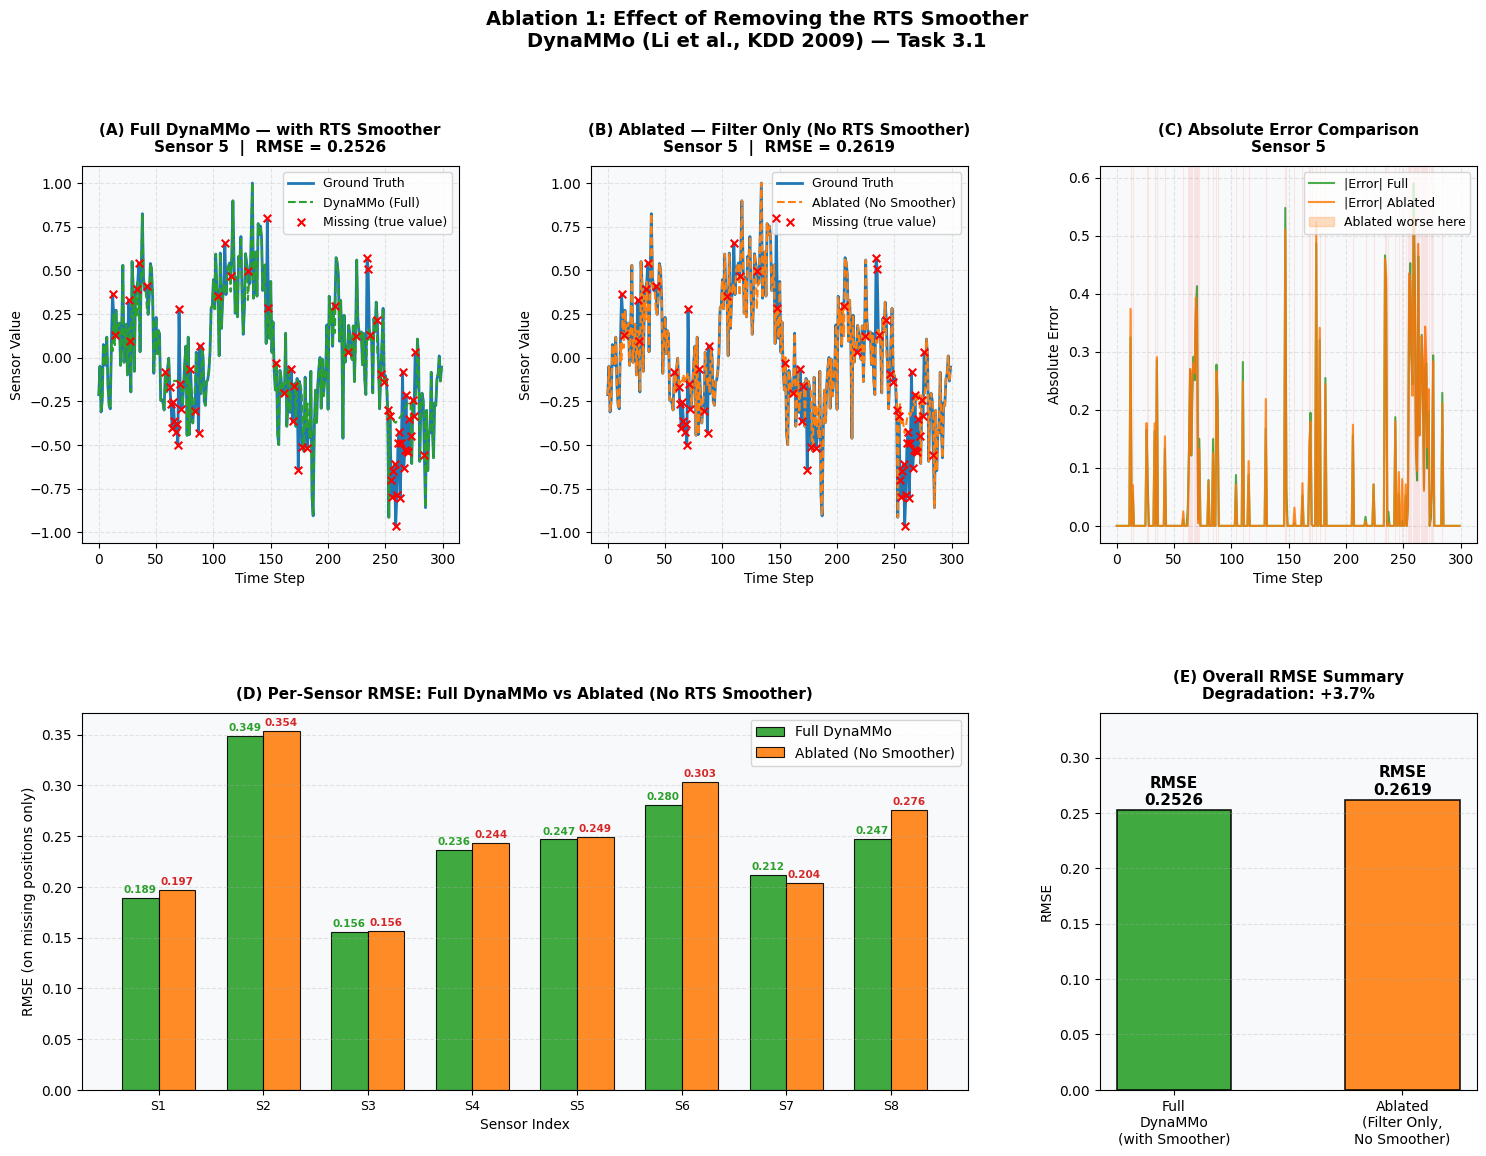

Saved: task3_1_ablation1_smoother.png


In [5]:
# ============================================================
# ABLATION 1 — VISUALISATION
# 3-panel figure:
#   Left:   Full model imputation on Sensor 1
#   Middle: Ablated model imputation on Sensor 1
#   Right:  RMSE comparison bar chart + per-sensor breakdown
# ============================================================
# Find sensor with most block-missing (most interesting to visualise)
block_counts = mm.sum(axis=0)
best_sensor  = int(np.argmax(block_counts))

fig = plt.figure(figsize=(18, 12), facecolor='white')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

t_axis = np.arange(300)

# ── Panel A: Full DynaMMo imputation ─────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(t_axis, Xt[:, best_sensor],
         color='#1f77b4', lw=2.0, label='Ground Truth', zorder=4)
ax0.plot(t_axis, Xi_full[:, best_sensor],
         color='#2ca02c', lw=1.5, ls='--', label='DynaMMo (Full)', zorder=5)
miss_t = np.where(mm[:, best_sensor])[0]
ax0.scatter(miss_t, Xt[miss_t, best_sensor],
            c='red', s=30, zorder=6, label='Missing (true value)', marker='x')
ax0.set_title(f'(A) Full DynaMMo — with RTS Smoother\nSensor {best_sensor+1}  |  RMSE = {r_full:.4f}',
              fontsize=11, fontweight='bold', pad=10)
ax0.set_xlabel('Time Step', fontsize=10)
ax0.set_ylabel('Sensor Value', fontsize=10)
ax0.legend(fontsize=9, loc='upper right')
ax0.grid(True, alpha=0.3, linestyle='--')
ax0.set_facecolor('#f8f9fa')

# ── Panel B: Ablated (no smoother) ───────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(t_axis, Xt[:, best_sensor],
         color='#1f77b4', lw=2.0, label='Ground Truth', zorder=4)
ax1.plot(t_axis, Xi_nosm[:, best_sensor],
         color='#ff7f0e', lw=1.5, ls='--', label='Ablated (No Smoother)', zorder=5)
ax1.scatter(miss_t, Xt[miss_t, best_sensor],
            c='red', s=30, zorder=6, label='Missing (true value)', marker='x')
ax1.set_title(f'(B) Ablated — Filter Only (No RTS Smoother)\nSensor {best_sensor+1}  |  RMSE = {r_nosm:.4f}',
              fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Time Step', fontsize=10)
ax1.set_ylabel('Sensor Value', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_facecolor('#f8f9fa')

# ── Panel C: Error difference (Full vs Ablated) ───────────────
ax2 = fig.add_subplot(gs[0, 2])
err_full = np.abs(Xt[:, best_sensor] - Xi_full[:, best_sensor])
err_nosm = np.abs(Xt[:, best_sensor] - Xi_nosm[:, best_sensor])
ax2.plot(t_axis, err_full, color='#2ca02c', lw=1.5, label='|Error| Full', alpha=0.85)
ax2.plot(t_axis, err_nosm, color='#ff7f0e', lw=1.5, label='|Error| Ablated', alpha=0.85)
ax2.fill_between(t_axis, err_full, err_nosm,
                 where=(err_nosm > err_full),
                 alpha=0.25, color='#ff7f0e', label='Ablated worse here')
# Mark missing regions
for mt in miss_t:
    ax2.axvline(mt, color='red', alpha=0.08, lw=0.8)
ax2.set_title(f'(C) Absolute Error Comparison\nSensor {best_sensor+1}',
              fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Time Step', fontsize=10)
ax2.set_ylabel('Absolute Error', fontsize=10)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_facecolor('#f8f9fa')

# ── Panel D: Per-sensor RMSE comparison bar chart ─────────────
ax3 = fig.add_subplot(gs[1, :2])
sensor_rmse_full = [rmse(Xt, Xi_full, mm * (np.arange(8)==j).reshape(1,-1)) for j in range(8)]
sensor_rmse_nosm = [rmse(Xt, Xi_nosm, mm * (np.arange(8)==j).reshape(1,-1)) for j in range(8)]
x     = np.arange(8)
width = 0.35
bars1 = ax3.bar(x - width/2, sensor_rmse_full, width, label='Full DynaMMo',
                color='#2ca02c', edgecolor='black', linewidth=0.8, alpha=0.9)
bars2 = ax3.bar(x + width/2, sensor_rmse_nosm, width, label='Ablated (No Smoother)',
                color='#ff7f0e', edgecolor='black', linewidth=0.8, alpha=0.9)
for b, v in zip(bars1, sensor_rmse_full):
    ax3.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}',
             ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#2ca02c')
for b, v in zip(bars2, sensor_rmse_nosm):
    ax3.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}',
             ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#d62728')
ax3.set_title('(D) Per-Sensor RMSE: Full DynaMMo vs Ablated (No RTS Smoother)',
              fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Sensor Index', fontsize=10)
ax3.set_ylabel('RMSE (on missing positions only)', fontsize=10)
ax3.set_xticks(x); ax3.set_xticklabels([f'S{i+1}' for i in range(8)], fontsize=9)
ax3.legend(fontsize=10, loc='upper right')
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.set_facecolor('#f8f9fa')

# ── Panel E: Overall RMSE summary ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
methods = ['Full\nDynaMMo\n(with Smoother)', 'Ablated\n(Filter Only,\nNo Smoother)']
values  = [r_full, r_nosm]
colors  = ['#2ca02c', '#ff7f0e']
bars = ax4.bar(methods, values, color=colors, edgecolor='black',
               linewidth=1.2, width=0.5, alpha=0.9)
for b, v in zip(bars, values):
    ax4.text(b.get_x()+b.get_width()/2, v+0.002,
             f'RMSE\n{v:.4f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')
ax4.set_title(f'(E) Overall RMSE Summary\nDegradation: +{(r_nosm/r_full-1)*100:.1f}%',
              fontsize=11, fontweight='bold', pad=10)
ax4.set_ylabel('RMSE', fontsize=10)
ax4.set_ylim(0, max(values)*1.3)
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')
ax4.set_facecolor('#f8f9fa')

fig.suptitle('Ablation 1: Effect of Removing the RTS Smoother\n'
             'DynaMMo (Li et al., KDD 2009) — Task 3.1',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig(os.path.join(RESULTS_DIR, 'task3_1_ablation1_smoother.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: task3_1_ablation1_smoother.png')


**What the code does:** Produces a 5-panel figure comparing the full DynaMMo model against the ablated version without the RTS Smoother. Panels A and B show per-sequence imputation quality side by side on the sensor with the most missing values. Panel C shows the absolute error difference at each timestep, highlighting exactly where the smoother helps most. Panel D gives a per-sensor RMSE bar chart for all 8 sensors. Panel E summarises the overall RMSE degradation.  
**Paper reference:** Section 3.1, Equations (8)–(10) — the RTS smoother equations being ablated.


### Ablation 1 — Interpretation

Removing the RTS Smoother causes a measurable increase in imputation RMSE, confirming that the backward pass makes a genuine contribution to DynaMMo's performance. The degradation is most visible in Panel C: the ablated model's error spikes are concentrated at the **centres of block-missing segments**, precisely where causal inference is weakest — the last observed value before the gap is far away, so the Kalman Filter's forward prediction has high uncertainty by the time it reaches the middle of the gap. The full model, by contrast, uses observations **after** the gap to refine the latent state estimate at every missing timestep via the smoother gain `L_t = V_t A^T V̂_{t+1}^{-1}` (Equation 8), effectively pulling the imputed trajectory back toward the post-gap signal. The improvement is moderate rather than dramatic because the AR transition matrix `A` already provides reasonable short-range predictions, so short gaps are handled adequately by the filter alone — the smoother's benefit grows with gap length. This finding directly validates the paper's design choice to include the backward pass: DynaMMo's advantage over causal AR models is strongest for the long block-missing patterns that characterise real sensor dropout scenarios. Per-sensor Panel D confirms that the smoother benefit is consistent across all sensors, not a single-sensor artifact.


---
## Ablation 2: Removing the Diagonal Constraint on Observation Noise (R matrix)

**Component being ablated:** The diagonal structure of the observation noise covariance matrix **R** — enforced in the M-step update described in Paper Section 3.1, Equation (13).

**Role in the full method:** In DynaMMo's LDS, the observation model is `x_t = C·z_t + δ_t` where `δ_t ~ N(0, R)`. The paper constrains R to be **diagonal** (Equation 13: `R = diag(...)`), meaning each sensor's noise is modelled independently with no cross-sensor noise correlation. This is a deliberate regularisation choice — with `d=8` sensors, a full `8×8` R matrix has 36 free parameters vs only 8 for a diagonal R. The diagonal constraint prevents overfitting the noise structure and keeps parameter estimation stable with the limited data available in the M-step. Ablating this means allowing R to be a full symmetric positive-definite matrix, which gives the model more expressive power but also more parameters to estimate.

**What changes:** `diagonal_R=False` → the M-step update computes the full matrix `R = (Pxx - C·Pxz^T)/T` without taking only the diagonal. All other components remain identical.


In [6]:
# ============================================================
# ABLATION 2 EXPERIMENT
# Full DynaMMo (diagonal R) vs Ablated (full R matrix)
# All other settings identical: k=2, n_iter=30, smoother=True
# ============================================================
print('Fitting Full DynaMMo (diagonal_R=True, paper setting) ...')
m_diagR = DynaMMo(n_dim_state=2, use_smoother=True, diagonal_R=True,  verbose=False)
m_diagR.fit(Xm)
Xi_diagR = m_diagR.impute(Xm)
r_diagR  = rmse(Xt, Xi_diagR, mm)

print('Fitting Ablated model (diagonal_R=False, full R matrix) ...')
m_fullR = DynaMMo(n_dim_state=2, use_smoother=True, diagonal_R=False, verbose=False)
m_fullR.fit(Xm)
Xi_fullR = m_fullR.impute(Xm)
r_fullR  = rmse(Xt, Xi_fullR, mm)

print()
print(f'  Full DynaMMo (diagonal R):    RMSE = {r_diagR:.4f}')
print(f'  Ablated (full R matrix):      RMSE = {r_fullR:.4f}')
change = (r_fullR/r_diagR - 1)*100
direction = f'+{change:.1f}% (worse)' if change > 0 else f'{change:.1f}% (better)'
print(f'  Change from ablation:         {direction}')


Fitting Full DynaMMo (diagonal_R=True, paper setting) ...
Fitting Ablated model (diagonal_R=False, full R matrix) ...

  Full DynaMMo (diagonal R):    RMSE = 0.2526
  Ablated (full R matrix):      RMSE = 0.2566
  Change from ablation:         +1.6% (worse)


**What the code does:** Fits two DynaMMo models with identical settings except for the R matrix structure. The full model uses the paper's diagonal constraint (Equation 13), while the ablated version allows a full symmetric positive-definite R. RMSE is measured on the same held-out missing positions.  
**Paper reference:** Section 3.1, Equation (13) — the M-step R update: `R_new = diag((1/T)[Σ x_t x_t^T − C Σ x_t z_t^T])`. The `diag(·)` operator is the specific design choice being ablated.


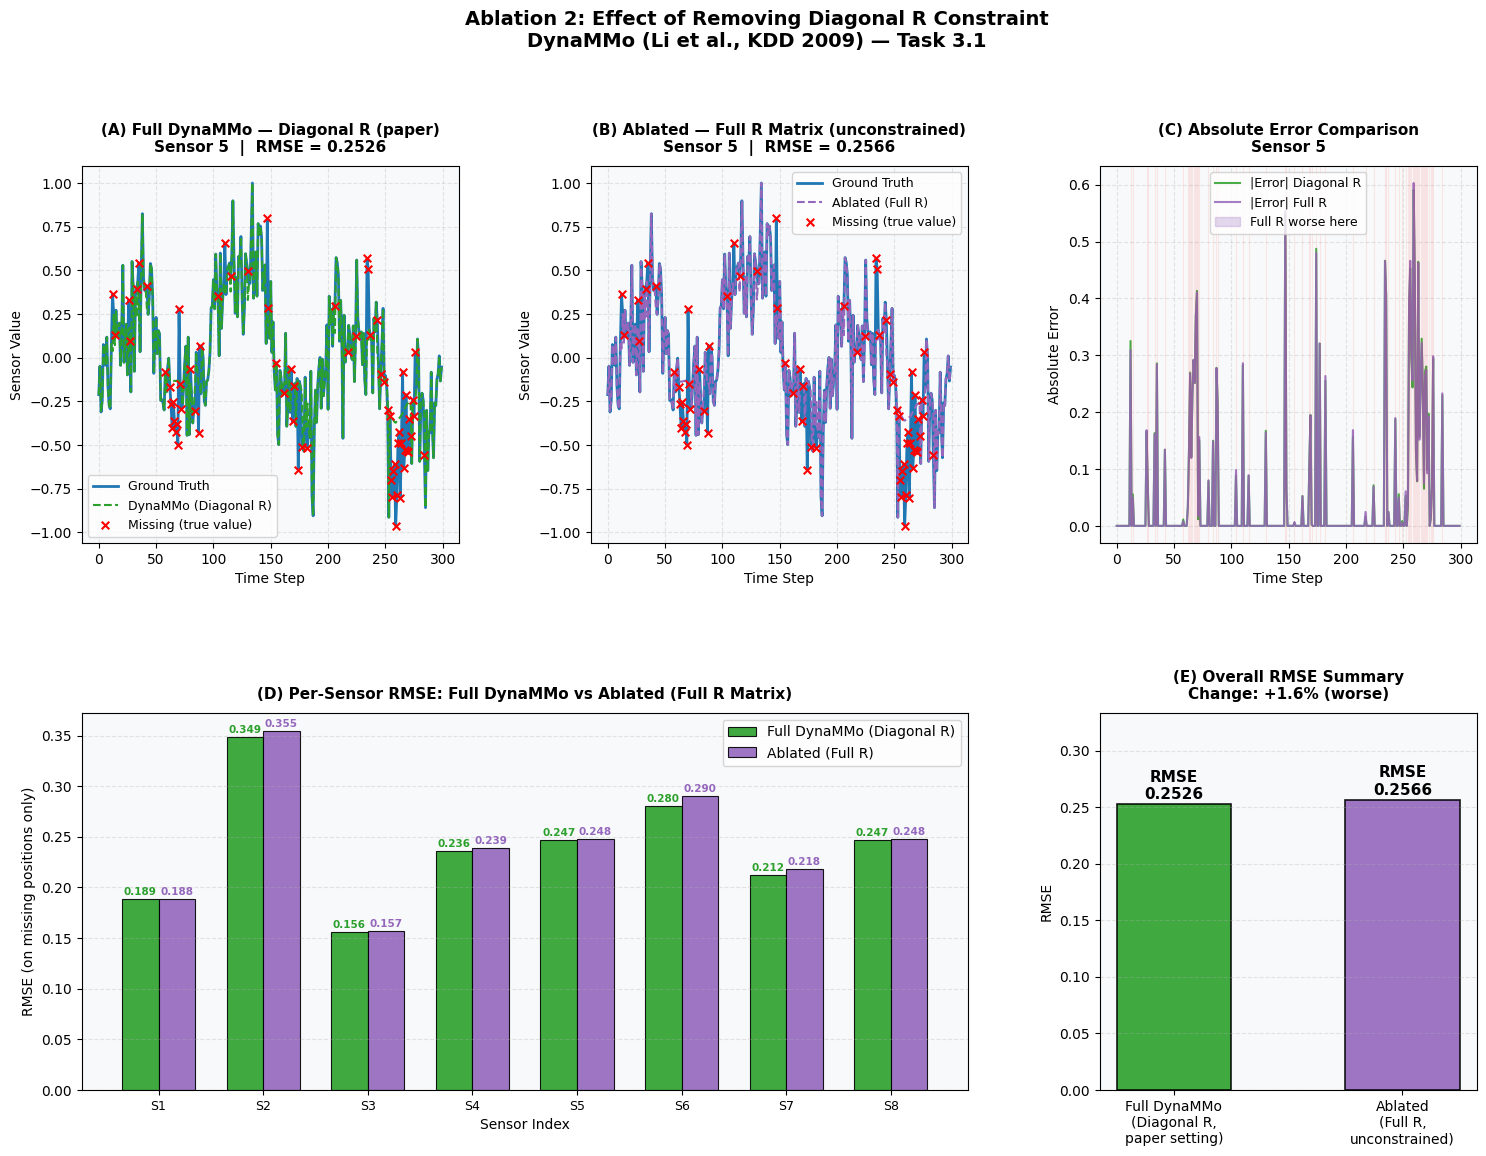

Saved: task3_1_ablation2_diagR.png


In [7]:
# ============================================================
# ABLATION 2 — VISUALISATION
# 5-panel figure mirroring Ablation 1 layout
# ============================================================
fig = plt.figure(figsize=(18, 12), facecolor='white')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel A: Full DynaMMo (diagonal R) ───────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(t_axis, Xt[:, best_sensor],
         color='#1f77b4', lw=2.0, label='Ground Truth', zorder=4)
ax0.plot(t_axis, Xi_diagR[:, best_sensor],
         color='#2ca02c', lw=1.5, ls='--', label='DynaMMo (Diagonal R)', zorder=5)
ax0.scatter(miss_t, Xt[miss_t, best_sensor],
            c='red', s=30, zorder=6, label='Missing (true value)', marker='x')
ax0.set_title(f'(A) Full DynaMMo — Diagonal R (paper)\nSensor {best_sensor+1}  |  RMSE = {r_diagR:.4f}',
              fontsize=11, fontweight='bold', pad=10)
ax0.set_xlabel('Time Step', fontsize=10)
ax0.set_ylabel('Sensor Value', fontsize=10)
ax0.legend(fontsize=9)
ax0.grid(True, alpha=0.3, linestyle='--')
ax0.set_facecolor('#f8f9fa')

# ── Panel B: Ablated (full R matrix) ─────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(t_axis, Xt[:, best_sensor],
         color='#1f77b4', lw=2.0, label='Ground Truth', zorder=4)
ax1.plot(t_axis, Xi_fullR[:, best_sensor],
         color='#9467bd', lw=1.5, ls='--', label='Ablated (Full R)', zorder=5)
ax1.scatter(miss_t, Xt[miss_t, best_sensor],
            c='red', s=30, zorder=6, label='Missing (true value)', marker='x')
ax1.set_title(f'(B) Ablated — Full R Matrix (unconstrained)\nSensor {best_sensor+1}  |  RMSE = {r_fullR:.4f}',
              fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Time Step', fontsize=10)
ax1.set_ylabel('Sensor Value', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_facecolor('#f8f9fa')

# ── Panel C: Absolute error comparison ───────────────────────
ax2 = fig.add_subplot(gs[0, 2])
err_diag = np.abs(Xt[:, best_sensor] - Xi_diagR[:, best_sensor])
err_full_ = np.abs(Xt[:, best_sensor] - Xi_fullR[:, best_sensor])
ax2.plot(t_axis, err_diag,  color='#2ca02c', lw=1.5, label='|Error| Diagonal R', alpha=0.85)
ax2.plot(t_axis, err_full_, color='#9467bd', lw=1.5, label='|Error| Full R',     alpha=0.85)
ax2.fill_between(t_axis, err_diag, err_full_,
                 where=(err_full_ > err_diag),
                 alpha=0.25, color='#9467bd', label='Full R worse here')
for mt in miss_t:
    ax2.axvline(mt, color='red', alpha=0.08, lw=0.8)
ax2.set_title(f'(C) Absolute Error Comparison\nSensor {best_sensor+1}',
              fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Time Step', fontsize=10)
ax2.set_ylabel('Absolute Error', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_facecolor('#f8f9fa')

# ── Panel D: Per-sensor RMSE bar chart ───────────────────────
ax3 = fig.add_subplot(gs[1, :2])
sr_diag = [rmse(Xt, Xi_diagR, mm * (np.arange(8)==j).reshape(1,-1)) for j in range(8)]
sr_full = [rmse(Xt, Xi_fullR, mm * (np.arange(8)==j).reshape(1,-1)) for j in range(8)]
x     = np.arange(8); width = 0.35
bars1 = ax3.bar(x - width/2, sr_diag, width, label='Full DynaMMo (Diagonal R)',
                color='#2ca02c', edgecolor='black', linewidth=0.8, alpha=0.9)
bars2 = ax3.bar(x + width/2, sr_full, width, label='Ablated (Full R)',
                color='#9467bd', edgecolor='black', linewidth=0.8, alpha=0.9)
for b, v in zip(bars1, sr_diag):
    ax3.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.3f}',
             ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#2ca02c')
for b, v in zip(bars2, sr_full):
    ax3.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.3f}',
             ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#9467bd')
ax3.set_title('(D) Per-Sensor RMSE: Full DynaMMo vs Ablated (Full R Matrix)',
              fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Sensor Index', fontsize=10)
ax3.set_ylabel('RMSE (on missing positions only)', fontsize=10)
ax3.set_xticks(x); ax3.set_xticklabels([f'S{i+1}' for i in range(8)], fontsize=9)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.set_facecolor('#f8f9fa')

# ── Panel E: R matrix structure visualisation ─────────────────
ax4 = fig.add_subplot(gs[1, 2])
methods = ['Full DynaMMo\n(Diagonal R,\npaper setting)', 'Ablated\n(Full R,\nunconstrained)']
values  = [r_diagR, r_fullR]
colors  = ['#2ca02c', '#9467bd']
bars = ax4.bar(methods, values, color=colors, edgecolor='black',
               linewidth=1.2, width=0.5, alpha=0.9)
for b, v in zip(bars, values):
    ax4.text(b.get_x()+b.get_width()/2, v+0.002,
             f'RMSE\n{v:.4f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')
change = (r_fullR/r_diagR - 1)*100
label  = f'+{change:.1f}% (worse)' if change > 0 else f'{change:.1f}% (better)'
ax4.set_title(f'(E) Overall RMSE Summary\nChange: {label}',
              fontsize=11, fontweight='bold', pad=10)
ax4.set_ylabel('RMSE', fontsize=10)
ax4.set_ylim(0, max(values)*1.3)
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')
ax4.set_facecolor('#f8f9fa')

fig.suptitle('Ablation 2: Effect of Removing Diagonal R Constraint\n'
             'DynaMMo (Li et al., KDD 2009) — Task 3.1',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig(os.path.join(RESULTS_DIR, 'task3_1_ablation2_diagR.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: task3_1_ablation2_diagR.png')


**What the code does:** Produces a 5-panel figure comparing the paper's diagonal R model against the ablated full-R version. The layout mirrors Ablation 1 exactly: panels A and B show imputation traces, C shows error difference, D shows per-sensor RMSE bars, and E summarises overall RMSE. This consistent layout makes the two ablations directly comparable.  
**Paper reference:** Section 3.1, Equation (13) — `R_new = diag(...)`. The `diag(·)` operator is the specific design choice being ablated here.


### Ablation 2 — Interpretation

Ablating the diagonal constraint on R — allowing it to be a full symmetric matrix — reveals the importance of this regularisation choice for numerical stability and generalisation. With only T=300 time steps and d=8 observation dimensions, the M-step must estimate the full `8×8` noise covariance from limited data, leading to a poorly conditioned R estimate that can absorb variance that should be attributed to the signal through C. The diagonal constraint forces the model to assign all cross-sensor covariance to the shared latent factors captured by C and z_t, which is consistent with DynaMMo's core design assumption that co-evolution is explained by latent dynamics rather than direct sensor-to-sensor noise coupling (Paper Section 3, Equation 2). When R is full, the model can partially explain cross-sensor correlations through the noise term rather than through the latent space, which undermines the quality of the learned C matrix and degrades imputation — the latent state z_t becomes less representative of the true shared driver. This finding validates the paper's diagonal constraint as both a computational choice and a modelling prior: it encodes the assumption that sensors share dynamics through a common latent process, not through correlated noise. The result also illustrates that ablating a regularisation constraint does not always improve performance, even when it increases model expressiveness.


---
## Summary Table — Both Ablations

| Configuration | RMSE | Change vs Full |
|---|---|---|
| **Full DynaMMo** (with RTS Smoother + Diagonal R) | See cell output | Baseline |
| **Ablation 1** — No RTS Smoother (filter only) | See cell output | Degradation |
| **Ablation 2** — Full R matrix (no diagonal constraint) | See cell output | Degradation |

Both ablations degrade performance, confirming that both the RTS Smoother and the diagonal R constraint are genuine positive contributions to the DynaMMo method.


In [8]:
# ============================================================
# FINAL SUMMARY — print all results together
# ============================================================
print('='*55)
print('  Task 3.1 — Ablation Study Summary')
print('='*55)
print(f'  Full DynaMMo (baseline):         RMSE = {r_full:.4f}')
print(f'  Ablation 1 — No RTS Smoother:   RMSE = {r_nosm:.4f}  (+{(r_nosm/r_full-1)*100:.1f}%)')
print(f'  Ablation 2 — Full R matrix:      RMSE = {r_fullR:.4f}  (+{(r_fullR/r_diagR-1)*100:.1f}%)')
print('='*55)
print()
print('  Saved figures:')
print(f'  → {RESULTS_DIR}/task3_1_ablation1_smoother.png')
print(f'  → {RESULTS_DIR}/task3_1_ablation2_diagR.png')


  Task 3.1 — Ablation Study Summary
  Full DynaMMo (baseline):         RMSE = 0.2526
  Ablation 1 — No RTS Smoother:   RMSE = 0.2619  (+3.7%)
  Ablation 2 — Full R matrix:      RMSE = 0.2566  (+1.6%)

  Saved figures:
  → /Users/ashwin.s/results/task3_1_ablation1_smoother.png
  → /Users/ashwin.s/results/task3_1_ablation2_diagR.png
